## Original Dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import json

In [2]:
data = []

with open("pan25-generative-ai-detection-task1-train\\train.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        data.append(json.loads(line))

df = pd.DataFrame(data)

print(df.head())

                                     id  \
0  ea468d03-1973-5039-86b2-ff225bb92c4e   
1  0d05f269-6d67-521d-9b5d-cc18f482c6c1   
2  c2ec79f3-da80-58f8-bef0-3e0ea7ab072f   
3  4ad37c58-0bb7-536b-997d-cfccabd0d094   
4  07747b0c-5051-5e0d-8096-b4d4ed8bd98e   

                                                text  \
0  Duke Ellington, a titan of jazz, revolutionize...   
1  I reflected on the shifting dynamics of media ...   
2  In F. Scott Fitzgerald's "The Great Gatsby," t...   
3  I still chuckle when I think about that time I...   
4  Yoga, originating in ancient India, encompasse...   

                          model  label   genre  
0          falcon3-10b-instruct      1  essays  
1                       o3-mini      1  essays  
2                        gpt-4o      1  essays  
3  deepseek-r1-distill-qwen-32b      1  essays  
4              gemini-2.0-flash      1  essays  


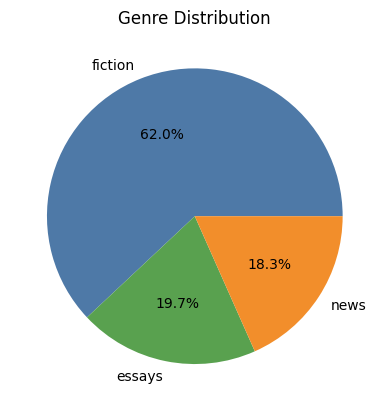

In [3]:
genre_counts = df["genre"].value_counts()

plt.figure()
genre_counts.plot.pie(autopct="%1.1f%%",colors=["#4E79A7","#59A14F","#F28E2B"])
plt.title("Genre Distribution")
plt.ylabel("")
plt.show()

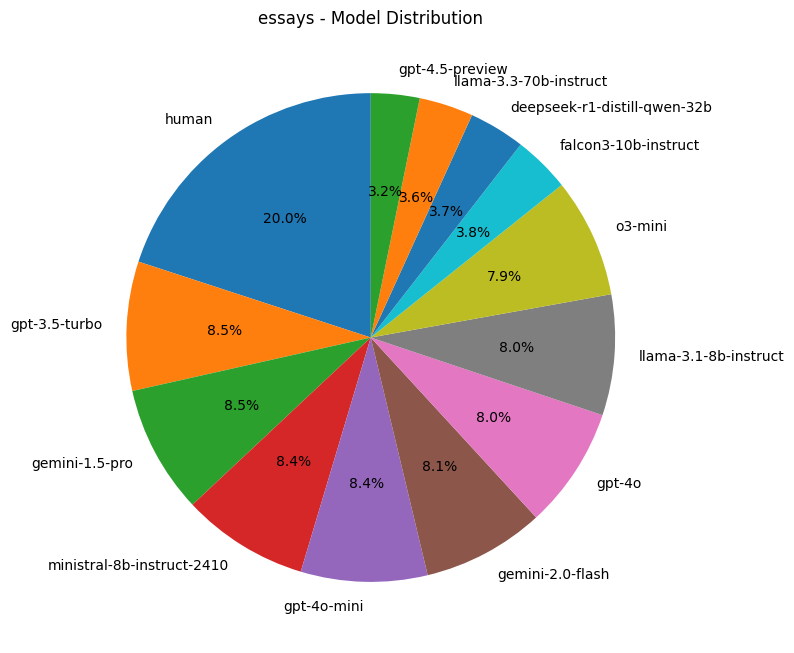

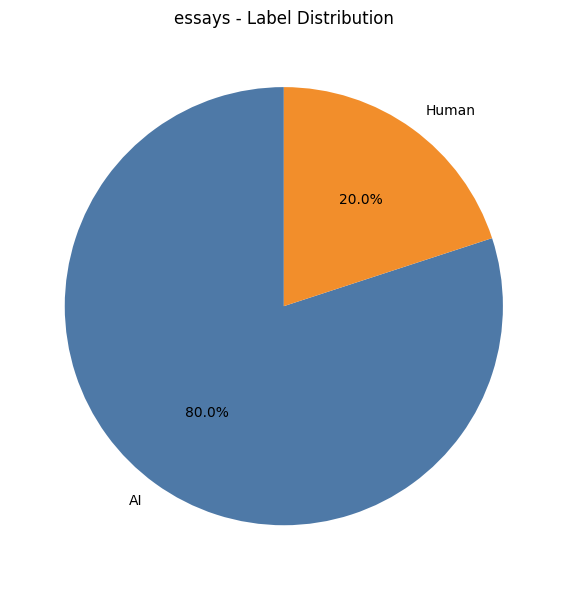

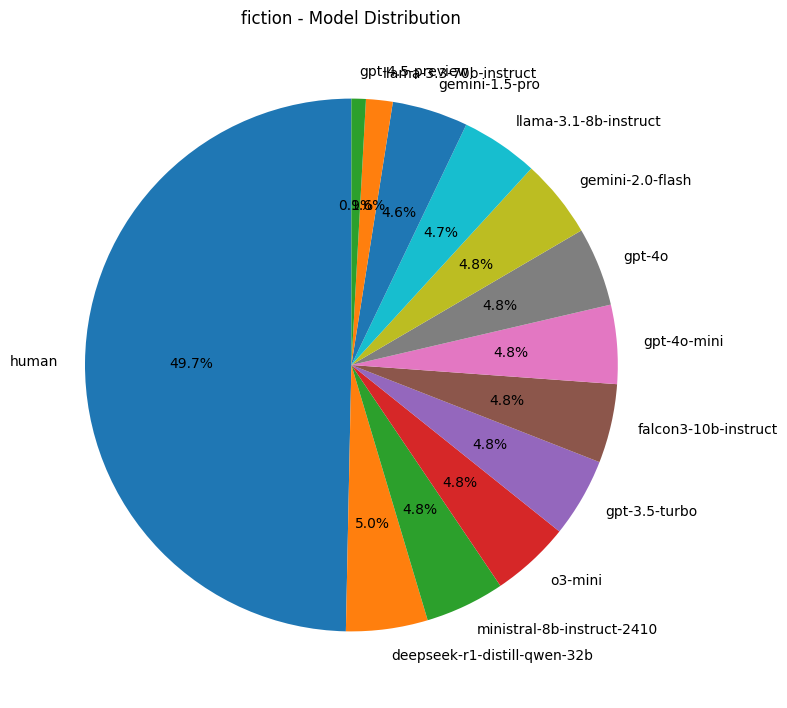

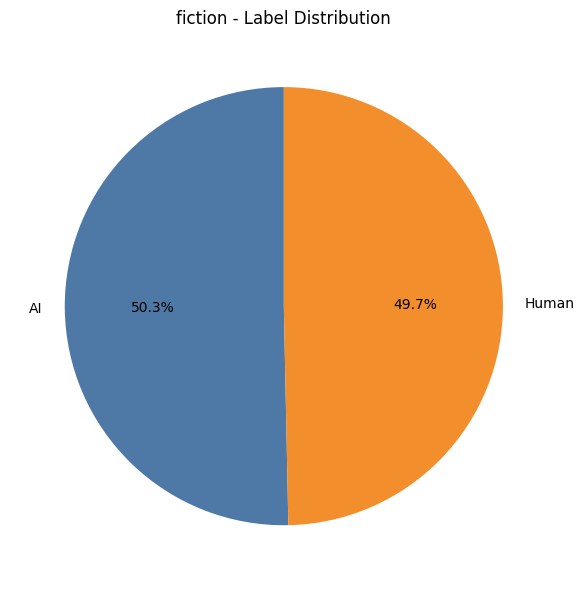

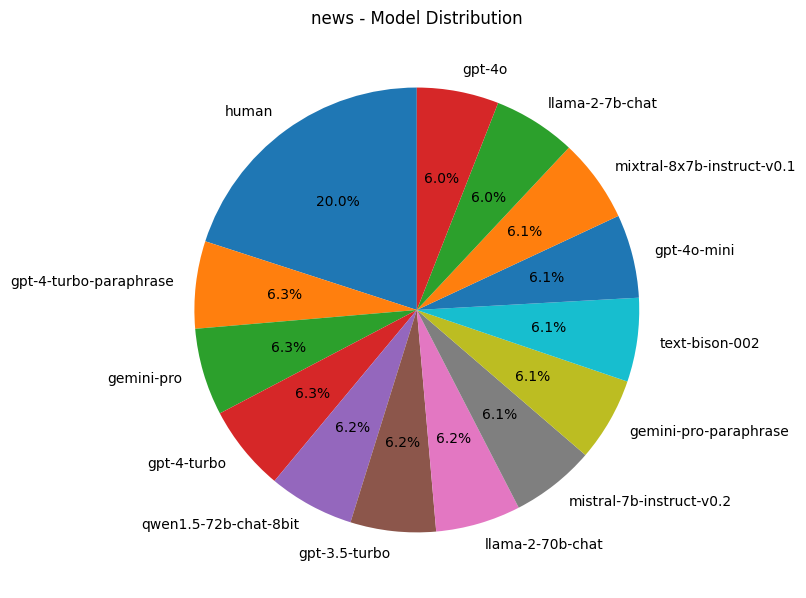

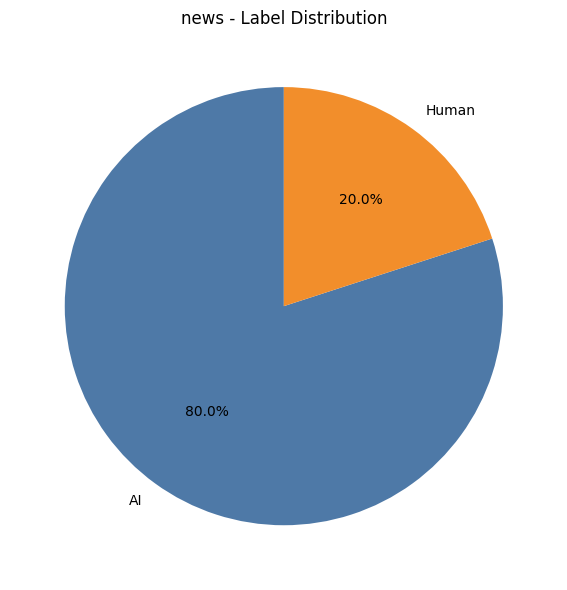

In [4]:
# -------- Pie Charts per Genre --------
genres = df["genre"].unique()

for genre in genres:
    subset = df[df["genre"] == genre]

    # ---- Model Distribution ----
    model_counts = subset["model"].value_counts()

    plt.figure(figsize=(8, 8))
    model_counts.plot.pie(
        autopct="%1.1f%%",
        startangle=90,
    )
    plt.title(f"{genre} - Model Distribution")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

    # ---- Label Distribution ----
    label_counts = subset["label"].value_counts()
    label_counts.index = label_counts.index.map({0: "Human", 1: "AI"})

    plt.figure(figsize=(6, 6))
    label_counts.plot.pie(
        autopct="%1.1f%%",
        startangle=90, colors=[
        "#4E79A7",
        "#F28E2B"]
    )
    plt.title(f"{genre} - Label Distribution")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

In [5]:
genre_tables = {}

for genre in genres:
    subset = df[df["genre"] == genre]
    table = subset["model"].value_counts().reset_index()
    table.columns = ["model", "count"]

    genre_tables[genre] = table

    print(f"\n=== {genre.upper()} ===")
    print(table)


=== ESSAYS ===
                           model  count
0                          human    931
1                  gpt-3.5-turbo    398
2                 gemini-1.5-pro    395
3     ministral-8b-instruct-2410    391
4                    gpt-4o-mini    390
5               gemini-2.0-flash    377
6                         gpt-4o    374
7          llama-3.1-8b-instruct    372
8                        o3-mini    368
9           falcon3-10b-instruct    175
10  deepseek-r1-distill-qwen-32b    173
11        llama-3.3-70b-instruct    167
12               gpt-4.5-preview    150

=== FICTION ===
                           model  count
0                          human   7300
1   deepseek-r1-distill-qwen-32b    728
2     ministral-8b-instruct-2410    709
3                        o3-mini    707
4                  gpt-3.5-turbo    706
5           falcon3-10b-instruct    704
6                    gpt-4o-mini    704
7                         gpt-4o    703
8               gemini-2.0-flash    702
9      

In [6]:
pd.crosstab(df["genre"], df["label"])

label,0,1
genre,,
essays,931,3730
fiction,7300,7397
news,870,3479


## Original Dataset vs After Balancing

In [7]:
def load_jsonl(path):
    df = pd.read_json(path, lines=True)
    
    df["label_name"] = df["label"].map({0: "Human", 1: "AI"})
    
    print(pd.crosstab(df["genre"], df["label_name"]))
    return df

print("Original Distribution:")
original_df = load_jsonl("pan25-generative-ai-detection-task1-train\\train.jsonl")

print("\nBalanced Distribution:")
balanced_df = load_jsonl("balanced_train_equal_genres.jsonl")

Original Distribution:
label_name    AI  Human
genre                  
essays      3730    931
fiction     7397   7300
news        3479    870

Balanced Distribution:
label_name   AI  Human
genre                 
essays      870    870
fiction     870    870
news        870    870


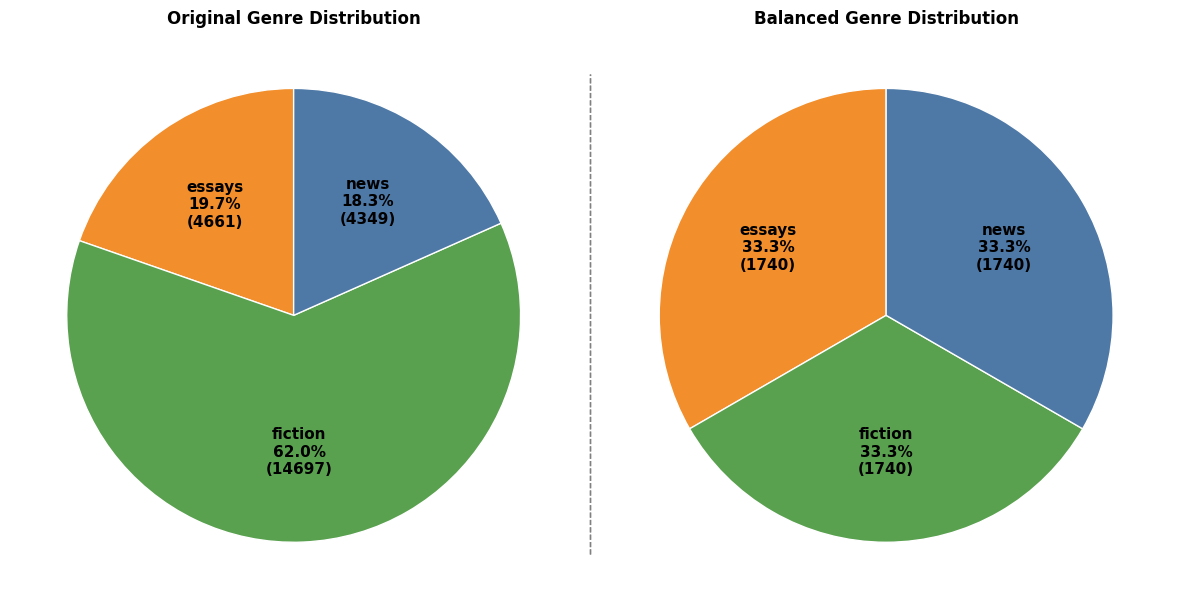

In [8]:
GENRE_COLORS = {
    "news": "#4E79A7",
    "fiction": "#59A14F",
    "essays": "#F28E2B"
}

def plot_genre_distribution(df1, df2, labels=("Original", "Balanced")):
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    for ax, df, title in zip(axes, [df1, df2], labels):
        counts = df['genre'].value_counts()

        # Ensure consistent order
        counts = counts.sort_index()

        colors = [GENRE_COLORS.get(g, "#BBBBBB") for g in counts.index]

        wedges, texts, autotexts = ax.pie(
            counts,
            labels=None,  # remove outer labels
            colors=colors,
            autopct='%1.1f%%',
            startangle=90,
            pctdistance=0.6,  # place text inside
            wedgeprops=dict(edgecolor='white')
        )

        # "Genre + %"
        for i, autotext in enumerate(autotexts):
            genre = counts.index[i]
            pct = autotext.get_text()
            count = counts.iloc[i]
            autotext.set_text(f"{genre}\n{pct}\n({count})")
            autotext.set_fontsize(11)
            autotext.set_weight("bold")
            autotext.set_color("black")

        ax.set_title(f"{title} Genre Distribution", fontsize=12, weight='bold')

        # ---- Divider line ----
        fig.lines.append(
            plt.Line2D(
                [0.5, 0.5],
                [0.1, 0.9],
                transform=fig.transFigure,
                linestyle='--',
                color='gray',
                linewidth=1
            )
        )

    plt.tight_layout()
    plt.show()


plot_genre_distribution(original_df, balanced_df)

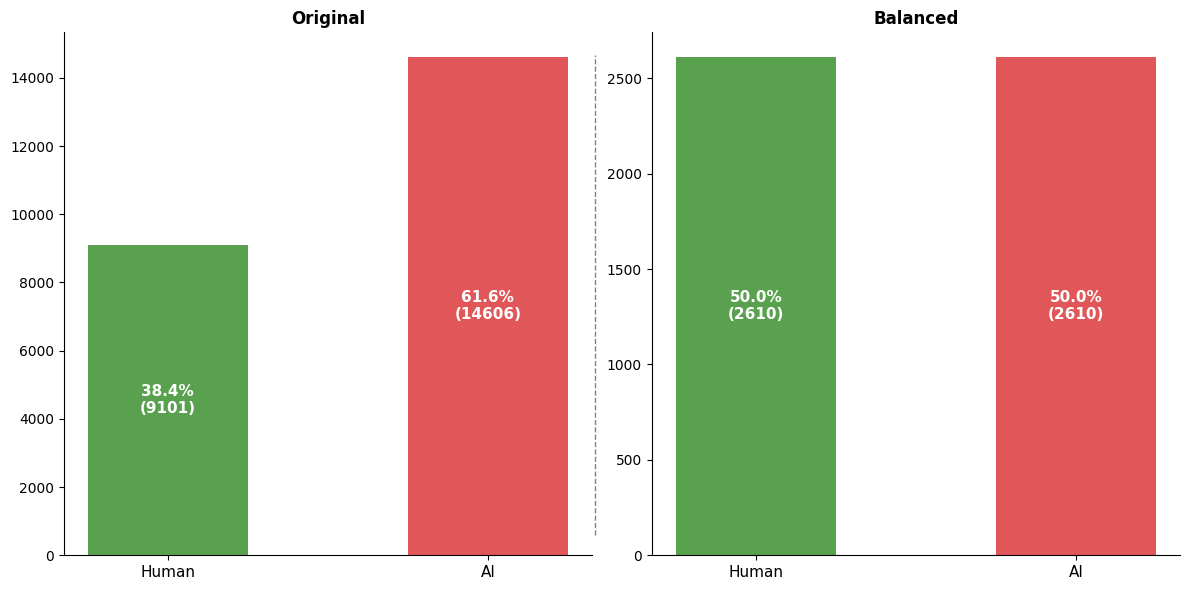

In [9]:
import numpy as np

COLORS = {
    "Human": "#59A14F",
    "AI": "#E15759"
}

def plot_human_ai_bar(df1, df2, labels=("Original", "Balanced")):
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    for ax, df, title in zip(axes, [df1, df2], labels):
        counts = df["label"].map({0: "Human", 1: "AI"}).value_counts()
        counts = counts.reindex(["Human", "AI"])  # ensure order

        total = counts.sum()
        percentages = (counts / total) * 100

        x = np.arange(len(counts))

        bars = ax.bar(
            x,
            counts.values,
            color=[COLORS[label] for label in counts.index],
            width=0.5
        )

        # ---- Labels on bars ----
        for i, bar in enumerate(bars):
            height = bar.get_height()
            pct = percentages.iloc[i]

            ax.text(
                bar.get_x() + bar.get_width()/2,
                height * 0.5,   # center inside bar
                f"{pct:.1f}%\n({int(height)})",
                ha='center',
                va='center',
                fontsize=11,
                weight='bold',
                color='white'
            )

        ax.set_xticks(x)
        ax.set_xticklabels(counts.index, fontsize=11)
        ax.set_title(title, fontsize=12, weight='bold')

        # Clean look
        ax.spines[['top', 'right']].set_visible(False)

    # ---- Divider line ----
    fig.lines.append(
        plt.Line2D(
            [0.5, 0.5],
            [0.1, 0.9],
            transform=fig.transFigure,
            linestyle='--',
            color='gray',
            linewidth=1
        )
    )

    plt.tight_layout()
    plt.show()


# -------------------------------
# Run
# -------------------------------
plot_human_ai_bar(original_df, balanced_df)

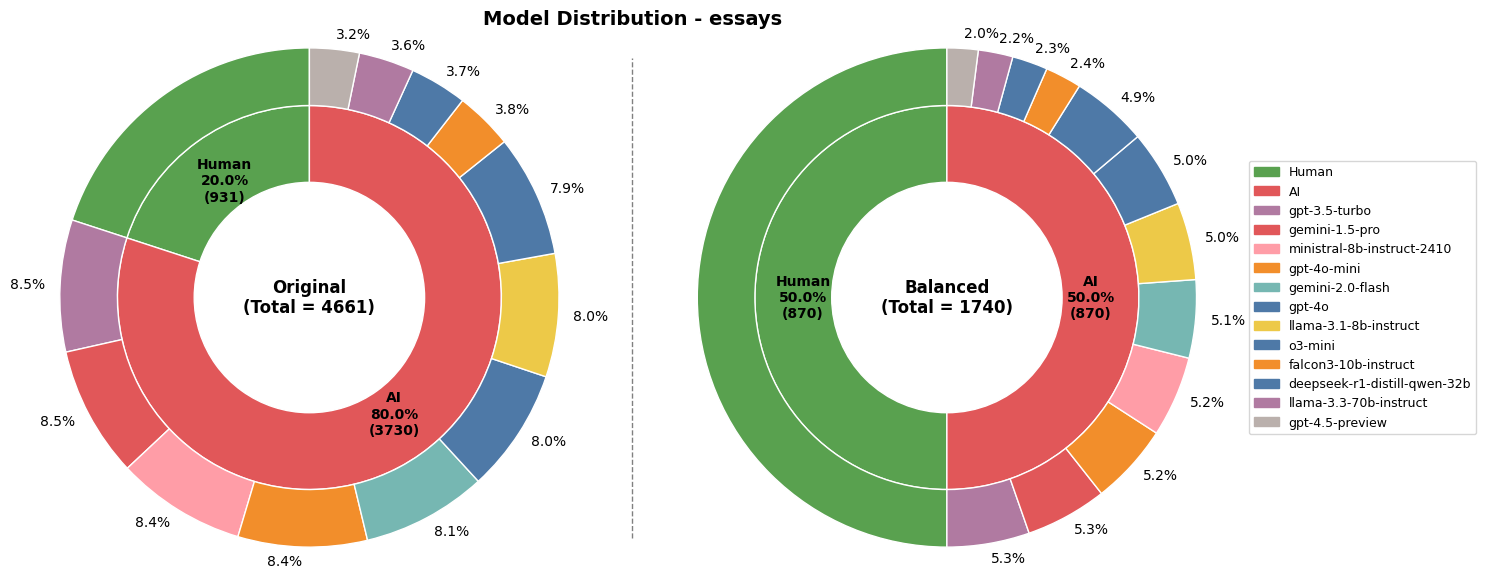

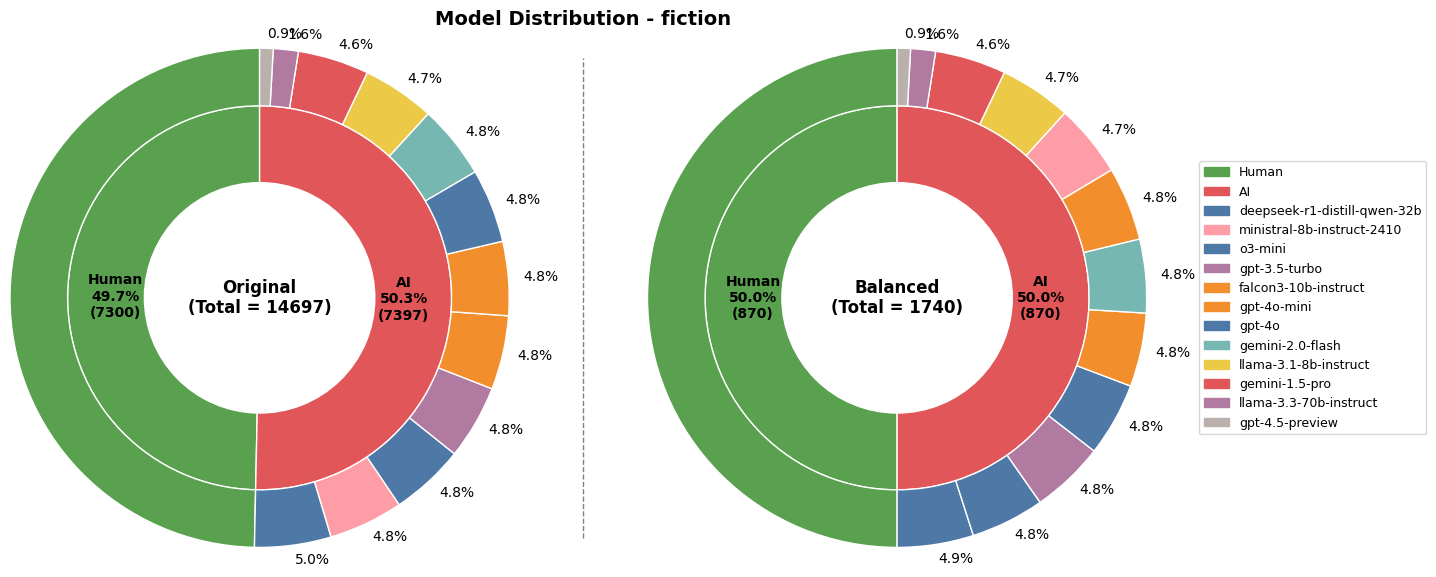

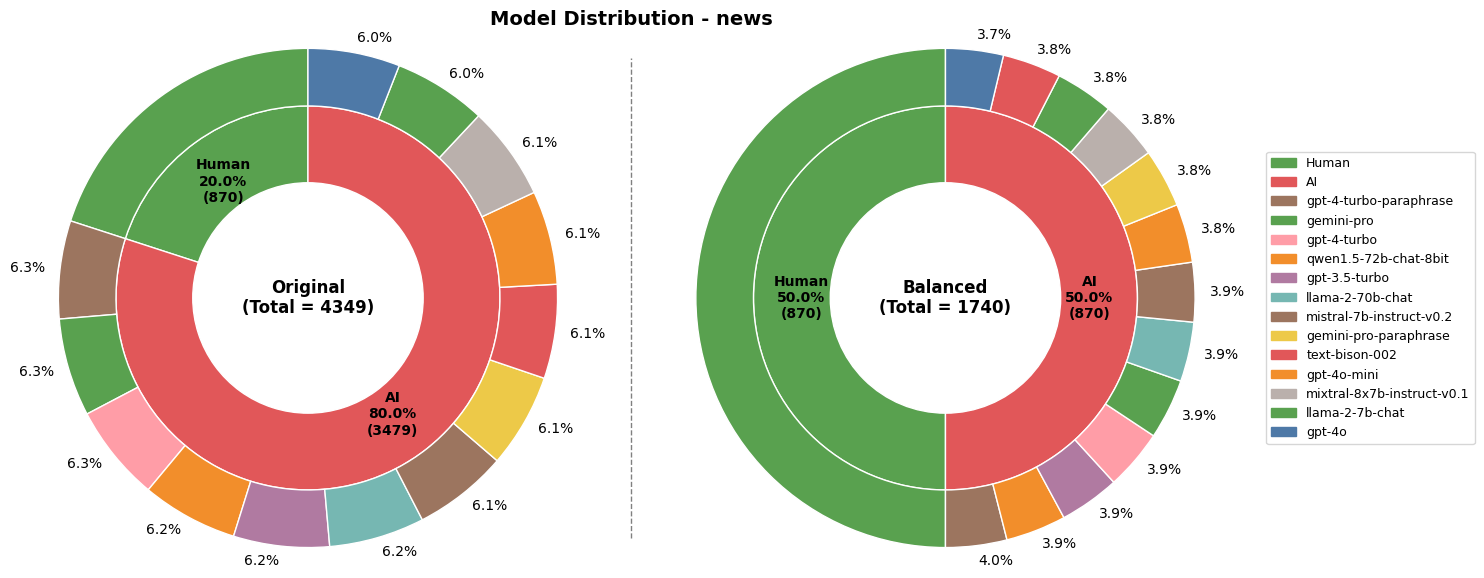

In [10]:
import itertools

# -------------------------------
# Color Map
# -------------------------------
def get_color_map(df1, df2):
    all_models = sorted(set(df1["model"]).union(set(df2["model"])))

    palette = [
        "#4E79A7", "#F28E2B", "#E15759", "#76B7B2",
        "#59A14F", "#EDC948", "#B07AA1", "#FF9DA7",
        "#9C755F", "#BAB0AC"
    ]

    color_cycle = itertools.cycle(palette)
    model_colors = {m: next(color_cycle) for m in all_models}

    # Fixed colors
    model_colors["Human"] = "#59A14F"
    model_colors["AI"] = "#E15759"

    return model_colors


# -------------------------------
# Plot Function
# -------------------------------
def plot_nested_donut(df1, df2, labels=("Original", "Balanced")):
    genres = sorted(set(df1['genre']).union(set(df2['genre'])))
    color_map = get_color_map(df1, df2)

    for genre in genres:
        fig, axes = plt.subplots(1, 2, figsize=(17,6))
        fig.suptitle(f"Model Distribution - {genre}", fontsize=14, weight='bold')

        legend_items = {}

        for ax, df, title in zip(axes, [df1, df2], labels):
            subset = df[df["genre"] == genre]
            total = len(subset)

            # ---- Inner ring ----
            human = (subset["label"] == 0).sum()
            ai = (subset["label"] == 1).sum()

            inner_sizes = [human, ai]
            inner_labels = [
                f"Human\n{human/total*100:.1f}%\n({human})",
                f"AI\n{ai/total*100:.1f}%\n({ai})"
            ]
            inner_colors = [color_map["Human"], color_map["AI"]]

            # ---- Outer ring (FIXED) ----
            ai_subset = subset[subset["label"] == 1]
            model_counts = ai_subset["model"].value_counts()

            # Human stays whole, AI is split
            outer_sizes = [human] + model_counts.tolist()

            outer_colors = (
                [color_map["Human"]] +
                [color_map[m] for m in model_counts.index]
            )

            # Hide human label on outer ring
            outer_labels = [""] + [
                f"{count/total*100:.1f}%" for count in model_counts
            ]

            # ---- Plot ----
            # INNER ring
            ax.pie(
                inner_sizes,
                radius=1,
                labels=inner_labels,
                colors=inner_colors,
                startangle=90,
                labeldistance=0.75,
                textprops={'ha': 'center', 'va': 'center', 'fontweight': 'bold'},
                wedgeprops=dict(width=0.4, edgecolor='white')
            )

            # OUTER ring
            ax.pie(
                outer_sizes,
                radius=1.3,
                labels=outer_labels,
                colors=outer_colors,
                startangle=90,
                labeldistance=1.06,
                wedgeprops=dict(width=0.3, edgecolor='white')
            )

            # ---- Legend collection ----
            for lbl in ["Human", "AI"] + list(model_counts.index):
                legend_items[lbl] = color_map[lbl]

            # ---- Center text ----
            ax.text(
                0, 0,
                f"{title}\n(Total = {total})",
                ha='center',
                va='center',
                fontsize=12,
                weight='bold'
            )

        # ---- Layout Fixes ----
        axes[0].set_position([0.15, 0.1, 0.32, 0.8])
        axes[1].set_position([0.525, 0.1, 0.32, 0.8])

        # ---- Legend ----
        handles = [
            plt.Rectangle((0, 0), 1, 1, color=color)
            for color in legend_items.values()
        ]

        fig.legend(
            handles,
            legend_items.keys(),
            loc="center right",
            bbox_to_anchor=(1, 0.5),
            fontsize=9
        )

        # ---- Divider line ----
        fig.lines.append(
            plt.Line2D(
                [0.5, 0.5],
                [0.1, 0.9],
                transform=fig.transFigure,
                linestyle='--',
                color='gray',
                linewidth=1
            )
        )

        plt.show()


# -------------------------------
# Run
# -------------------------------
plot_nested_donut(original_df, balanced_df)

## Train-Test-Val Split EDA

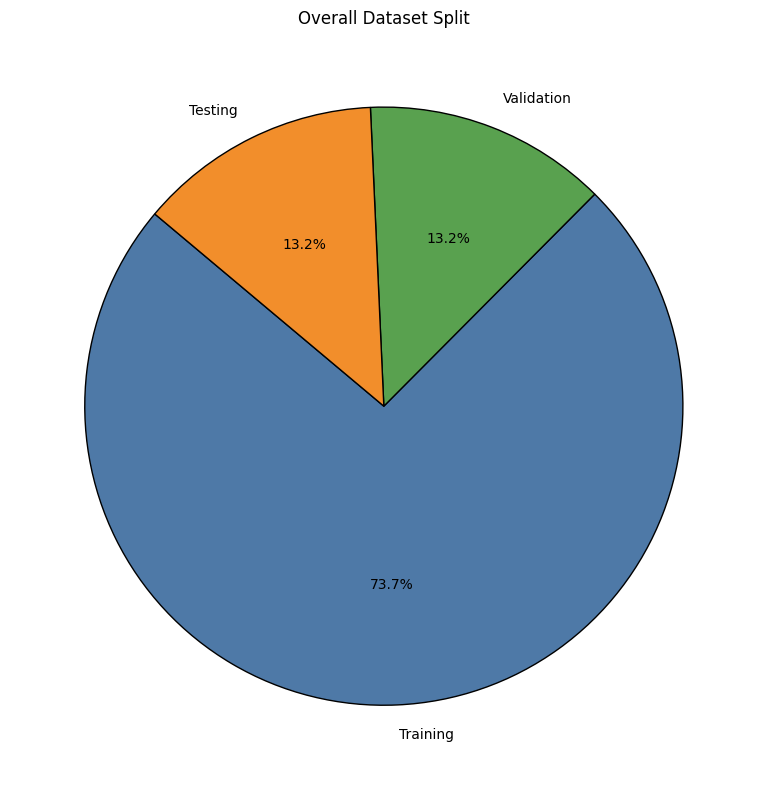

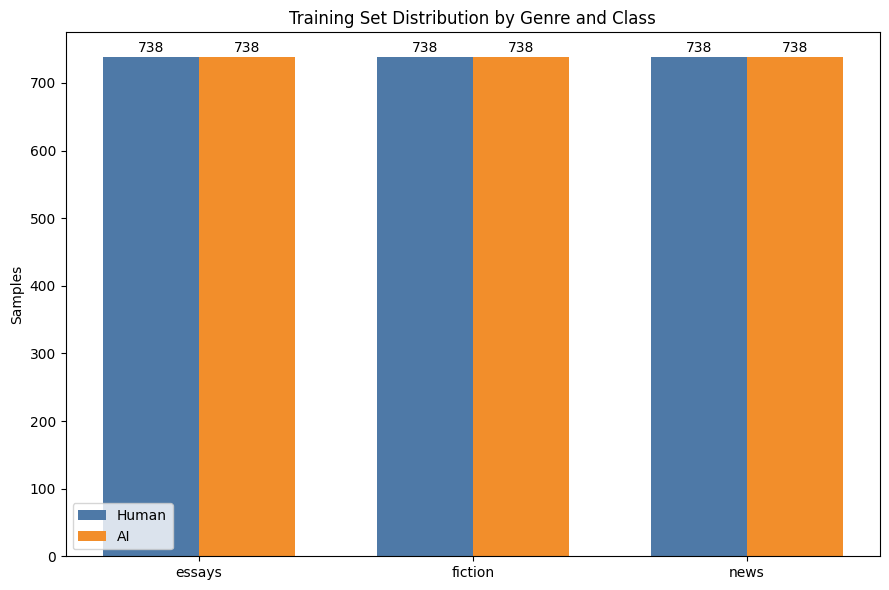

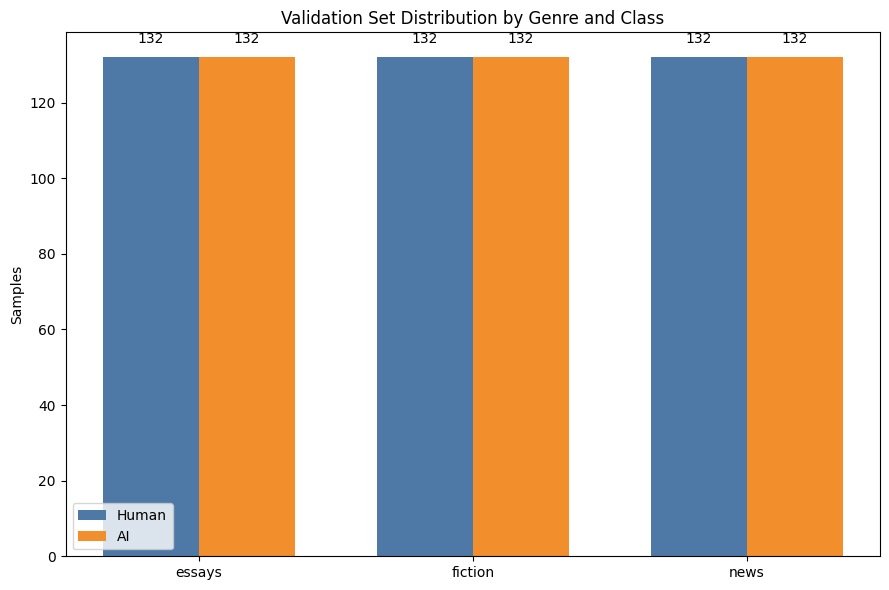

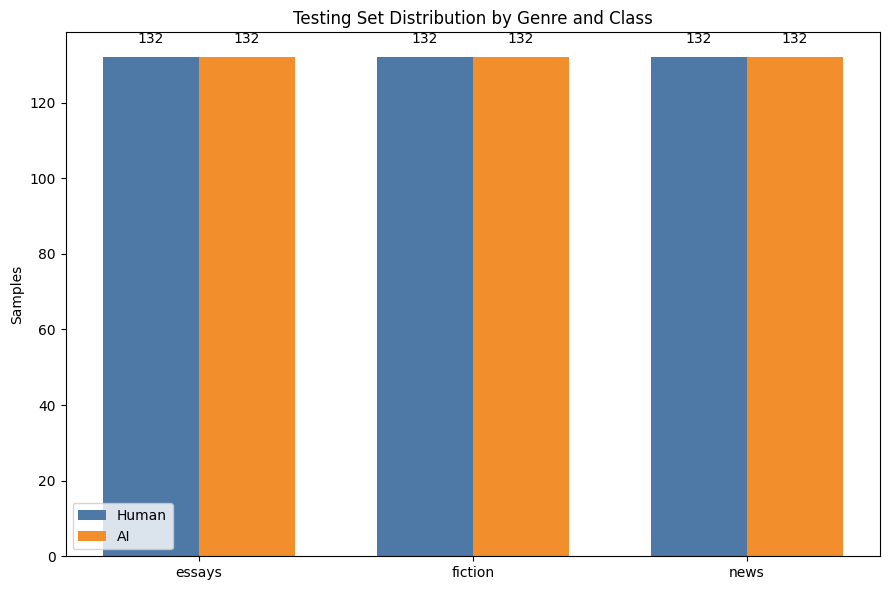

In [11]:
# ----------------------------------------
# Load JSONL files
# ----------------------------------------
def load_jsonl(path):
    data = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            data.append(json.loads(line))
    return pd.DataFrame(data)

train_df = load_jsonl("balanced_data\\training.jsonl")
val_df   = load_jsonl("balanced_data\\validation.jsonl")
test_df  = load_jsonl("balanced_data\\testing.jsonl")   # official PAN test set

# ----------------------------------------
# Dataset sizes
# ----------------------------------------
sizes = [len(train_df), len(val_df), len(test_df)]
labels = ["Training", "Validation", "Testing"]

# ----------------------------------------
# PIE CHART
# ----------------------------------------
plt.figure(figsize=(8,8))
plt.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%",
    startangle=140,
    colors=[
        "#4E79A7",
        "#59A14F",
        "#F28E2B"],
    wedgeprops={"edgecolor":"black"}
)
plt.title("Overall Dataset Split")
plt.tight_layout()
plt.show()

# ----------------------------------------
# BAR CHART FUNCTION
# ----------------------------------------
def plot_split_bars(df, title):

    genres = sorted(df["genre"].unique())

    human_counts = []
    ai_counts = []

    for genre in genres:
        g = df[df["genre"] == genre]

        human_counts.append(len(g[g["label"] == 0]))
        ai_counts.append(len(g[g["label"] == 1]))

    x = np.arange(len(genres))
    width = 0.35

    plt.figure(figsize=(9,6))
    bars1 = plt.bar(x - width/2, human_counts, width, label="Human", color="#4E79A7")
    bars2 = plt.bar(x + width/2, ai_counts, width, label="AI", color="#F28E2B")

    plt.xticks(x, genres)
    plt.ylabel("Samples")
    plt.title(title)
    plt.legend()

    # values on top
    for bars in [bars1, bars2]:
        for bar in bars:
            h = bar.get_height()
            plt.text(
                bar.get_x() + bar.get_width()/2,
                h + 3,
                str(int(h)),
                ha="center",
                va="bottom",
                fontsize=10
            )

    plt.tight_layout()
    plt.show()

# ----------------------------------------
# TRAIN / VAL / TEST BAR CHARTS
# ----------------------------------------
plot_split_bars(train_df, "Training Set Distribution by Genre and Class")
plot_split_bars(val_df,   "Validation Set Distribution by Genre and Class")
plot_split_bars(test_df,  "Testing Set Distribution by Genre and Class")